<a href="https://colab.research.google.com/github/m22aie202/FM_GenAI/blob/main/m22aie202_assign_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [104]:
#Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms
from torchvision.utils import make_grid

import matplotlib.pyplot as plt
import numpy as np

In [105]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [106]:
#Loading dataset CIFAR-10
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [107]:
#Encoder
class Encoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

        self.flatten_dim = 256 * 4 * 4
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc_mu(x), self.fc_logvar(x)

In [108]:
#Reparameterization
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

In [109]:
#decoder same as per encoder

class Decoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()

        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 256, 4, 4)
        return self.deconv(x)

In [110]:
#now model load
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

In [111]:
#get the model
latent_dim = 256
model = VAE(latent_dim).to(device)


In [112]:
#loss function
def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    recon_loss = F.mse_loss(recon_x, x, reduction="sum")
    kl = -0.2 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl, recon_loss, kl

In [113]:
#optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [114]:
epochs = 100
beta = 0.5

In [115]:
train_losses = []
recon_losses = []
kl_losses = []

In [116]:
#training model
for epoch in range(epochs):
    model.train()

    total_loss = 0
    total_recon = 0
    total_kl = 0

    for x, _ in train_loader:
        x = x.to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(x)

        loss, r_loss, kl = vae_loss(recon, x, mu, logvar, beta)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += r_loss.item()
        total_kl += kl.item()

    avg_loss = total_loss / len(train_loader.dataset)
    avg_recon = total_recon / len(train_loader.dataset)
    avg_kl = total_kl / len(train_loader.dataset)

    train_losses.append(avg_loss)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)

    print(f"Epoch [{epoch+1}/{epochs}]  "
          f"Loss: {avg_loss:.4f}  Recon: {avg_recon:.4f}  KL: {avg_kl:.4f}")

Epoch [1/100]  Loss: 76.0989  Recon: 63.5360  KL: 25.1259
Epoch [2/100]  Loss: 52.6507  Recon: 40.0895  KL: 25.1225
Epoch [3/100]  Loss: 48.8186  Recon: 35.6574  KL: 26.3224
Epoch [4/100]  Loss: 47.1725  Recon: 33.5910  KL: 27.1631
Epoch [5/100]  Loss: 46.1854  Recon: 32.3345  KL: 27.7020
Epoch [6/100]  Loss: 45.6702  Recon: 31.6157  KL: 28.1091
Epoch [7/100]  Loss: 45.0529  Recon: 30.8328  KL: 28.4403
Epoch [8/100]  Loss: 44.6892  Recon: 30.3289  KL: 28.7206
Epoch [9/100]  Loss: 44.5997  Recon: 30.1352  KL: 28.9290
Epoch [10/100]  Loss: 44.1753  Recon: 29.6168  KL: 29.1170
Epoch [11/100]  Loss: 43.9599  Recon: 29.3358  KL: 29.2484
Epoch [12/100]  Loss: 43.7572  Recon: 29.0694  KL: 29.3756
Epoch [13/100]  Loss: 43.6411  Recon: 28.8757  KL: 29.5307
Epoch [14/100]  Loss: 43.4139  Recon: 28.6130  KL: 29.6020
Epoch [15/100]  Loss: 43.3794  Recon: 28.5293  KL: 29.7003
Epoch [16/100]  Loss: 43.1554  Recon: 28.2499  KL: 29.8110
Epoch [17/100]  Loss: 43.0466  Recon: 28.0971  KL: 29.8990
Epoch 

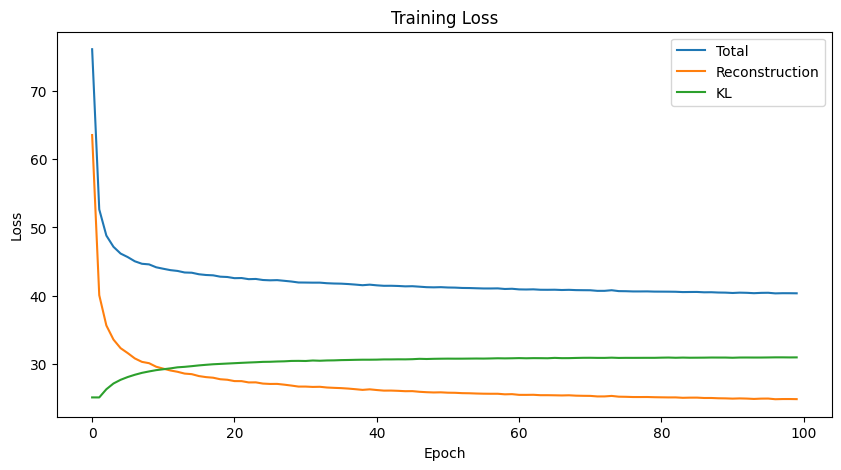

In [117]:
#plotting
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Total")
plt.plot(recon_losses, label="Reconstruction")
plt.plot(kl_losses, label="KL")
plt.legend()
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [118]:
torch.save(model.state_dict(), "m22aie202_vae_cifar.pth")

In [119]:
model.eval()

with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    samples = model.decoder(z).cpu()

In [120]:
grid = make_grid(samples, nrow=4)

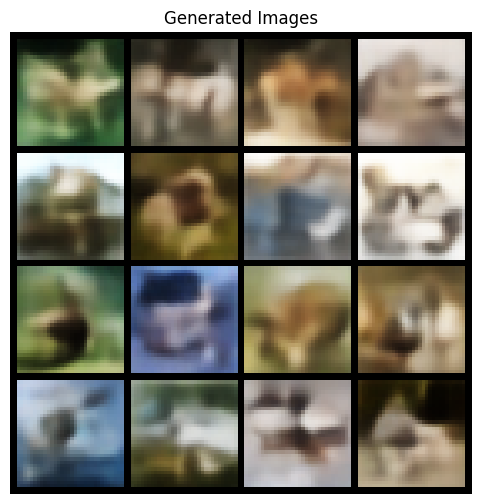

In [121]:
plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid, (1,2,0)))
plt.axis("off")
plt.title("Generated Images")
plt.show()